# 0. CONTEXTO DE LA EMPRESA Y CARGA DEL DATASET: AIRBnB

Airbnb es una plataforma en línea y aplicación móvil que conecta a viajeros con anfitriones locales que ofrecen alojamiento temporal, como habitaciones, departamentos o casas enteras, a menudo a precios más accesibles que los hoteles. Funciona bajo un modelo de economía colaborativa, permitiendo reservar experiencias personalizadas en cualquier lugar del mundo y garantizando la seguridad mediante reseñas mutuas entre huéspedes y anfitriones.

## ¿QUÉ ES AIRBNB?
Es un marketplace digital que conecta a dos tipos de usuarios:

- Hosts (Anfitriones): Personas que ofrecen sus propiedades (desde una habitación compartida hasta una mansión o un castillo) para alquiler a corto o largo plazo.

- Guests (Huéspedes): Viajeros que buscan alojamiento con una experiencia más local o económica que un hotel tradicional.

2. El Modelo de Negocio
Airbnb no es dueño de las propiedades; su valor reside en la plataforma y los datos. Sus ingresos provienen de:

- Comisiones por servicio: Cobran un porcentaje tanto al anfitrión como al huésped por cada reserva confirmada.

- Servicios adicionales: "Experiencias" (tours o actividades guiadas) y servicios de gestión para anfitriones.

## 0.1 CARGA DE DATOS

In [ ]:
# ============================================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================================================
# Dataset: Airbnb Price Prediction - New York City
# Estructura: ~74,000 listados de Airbnb en NYC con 16 variables que describen
#             características del anfitrión, ubicación, tipo de habitación,
#             precio y métricas de popularidad (reseñas, disponibilidad).
# ============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# INSTALAR Y DESCARGAR DATASET Y LIBRERIAS
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# 1. Definir la ruta local al archivo
# '../' sube un nivel a la carpeta principal, luego entra a 'data'
ruta_local = os.path.join('..', 'data', 'Train.csv') 

print(f"\nCargando dataset local desde: {ruta_local}")

# 2. Leer el archivo CSV
if os.path.exists(ruta_local):
    datos = pd.read_csv(ruta_local)
    print("¡Dataset cargado con éxito desde tu carpeta local!")
    display(datos.head(3))
else:
    print(f"❌ Error: No se encontró el archivo en {ruta_local}")
    print("Asegúrate de que el archivo se llame 'Train.csv' y esté dentro de la carpeta 'data'.")

Instalando kagglehub.

Cargando dataset local desde: ..\data\Train.csv
¡Dataset cargado con éxito desde tu carpeta local!


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0


## 0.2 VISUALIZACION DEL DATASET Y SU TAMAÑO

In [3]:
# ===========================================================================
# INFORMACION BASICA DEL DATASET(CONOCIMIENTO DEL TAMAÑO, COLUMNAS Y TIPOS)
# ===========================================================================
print("=" * 65)
print("DATASET CARGADO EXITOSAMENTE")
print("=" * 65)
print(f"  Filas    : {datos.shape[0]:,}")
print(f"  Columnas : {datos.shape[1]}")
print("=" * 65)
print(f"\nPrimeras 3 filas:\n{datos.head(3).to_string()}")


DATASET CARGADO EXITOSAMENTE
  Filas    : 74,111
  Columnas : 29

Primeras 3 filas:
        id  log_price property_type        room_type                                                                                                                                                                                                                                                                                                                amenities  accommodates  bathrooms  bed_type cancellation_policy  cleaning_fee city                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

## 0.3 VISUALIZACION DE TIPOS DE DATOS Y IDENTIFICACION DE VALORES NULOS

In [4]:
# ===========================================================================
# TIPOS DE DATOS Y VALORES NULOS
# ===========================================================================
print("=" * 65)
print("TIPOS DE DATOS Y VALORES NULOS")
print("=" * 65)
info_df = pd.DataFrame({
    'Tipo': datos.dtypes,
    'No_Nulos': datos.notna().sum(),
    'Nulos': datos.isna().sum(),
    '% Nulos': (datos.isna().sum() / len(datos) * 100).round(2)
})
print(info_df.to_string())

TIPOS DE DATOS Y VALORES NULOS
                           Tipo  No_Nulos  Nulos  % Nulos
id                        int64     74111      0     0.00
log_price               float64     74111      0     0.00
property_type               str     74111      0     0.00
room_type                   str     74111      0     0.00
amenities                   str     74111      0     0.00
accommodates              int64     74111      0     0.00
bathrooms               float64     73911    200     0.27
bed_type                    str     74111      0     0.00
cancellation_policy         str     74111      0     0.00
cleaning_fee               bool     74111      0     0.00
city                        str     74111      0     0.00
description                 str     74111      0     0.00
first_review                str     58247  15864    21.41
host_has_profile_pic        str     73923    188     0.25
host_identity_verified      str     73923    188     0.25
host_response_rate          str     55812

## 0.1 CANTIDAD DE DATOS CONSEGUIDOS

El dataset contiene **74,111 registros** y **29 variables** originales. Lo que nos da un volumen total de aproximadamente 2,146,000 datos, tambien se pueden apreciar valores nulos en diferentes variables, por lo que en la limpieza de datos en las variables categoricas se usara la media y para las numericas se usara la mediana ya que al tener menos del 1% de nulos se pueden imputar esos valores sin sesgar los datos.

Es un conjunto de datos bastante amplio el cual nos puede dar muchisimos aspectos a considerar para mejorar el negocio de AirBnB

---
## 0.2 🔡 DESCRIPCION DE LAS VARIABLES CATEGORICAS
#### **Nominales (Sin orden intrínseco)**

- **id:** Identificador único del registro (aunque es un número, funciona como etiqueta).
- **property_type:** Tipo de propiedad (Apartamento, Casa, Loft, etc.).
- **room_type:** Tipo de habitación (Habitación privada, Casa completa, Habitación compartida).
- **amenities:** Lista de servicios disponibles (Wifi, Cocina, Aire acondicionado).
- **city:**
 Ciudad donde se encuentra el alojamiento.
- **neighbourhood:** Barrio o colonia específica.
- **thumbnail_url:** Enlace a la imagen miniatura del anuncio.
- **zipcode:** Código postal (se trata como categoría porque no se suman ni se promedian).

#### **Binarias (Dos opciones)**

- **cleaning_fee:** Indica si se cobra o no una tarifa de limpieza (en tu tabla aparece como bool).
- **host_has_profile_pic:** Si el anfitrión tiene foto de perfil.
- **host_identity_verified:** Si el anfitrión ha verificado su identidad.
- **instant_bookable:** Si permite la reserva inmediata sin confirmación previa.

#### **Temporales (Fechas)**

- **first_review / last_review:** Fechas de la primera y última reseña.
- **host_since:** Fecha en la que el anfitrión se unió a la plataforma.

---
## 0.3 🔢 DESCRIPCION DE LAS VARIABLES NUMERICAS

- **log_price:** El logaritmo del precio. Se usa para normalizar la distribución del costo de la renta.
- **accommodates:** Capacidad máxima de personas que pueden alojarse.
- **bathrooms:** Número de baños. Puede tener decimales (ej. 1.5 baños) por los baños de visita.
- **latitude / longitude:** Coordenadas geográficas exactas de la ubicación del inmueble.
- **number_of_reviews:** Cantidad total de reseñas que ha recibido el alojamiento.
- **review_scores_rating:** Calificación promedio otorgada por los usuarios (generalmente de 0 a 100).
- **bedrooms:** Cantidad de habitaciones disponibles.
- **beds:** Cantidad de camas físicas en el alojamiento.


# 1. LIMPIEZA DE DATOS

In [5]:
# ===========================================================================
# LIMPIEZA DE DATOS
# ===========================================================================

import sys
import os

print("\nIniciando limpieza de datos...")

# Agregamos la carpeta principal (raíz) al camino de búsqueda de Python
sys.path.append(os.path.abspath(".."))

# Importamos tu función desde el archivo .py
from src.cleaning import LimpiezaProfunda

# Aplicamos la limpieza al dataset original (datos) 
# y lo guardamos en una nueva variable (datos_limpios)
datos_limpios = LimpiezaProfunda(datos)

print("¡Dataset limpiado correctamente!")

# Mostramos los datos limpios (asegúrate de usar la variable nueva)
display(datos_limpios.head(3))


Iniciando limpieza de datos...
¡Dataset limpiado correctamente!


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0


In [6]:
# ===========================================================================
# INFORMACION BASICA DEL DATASET DESPUES DE LA LIMPIEZA
# ===========================================================================
print("=" * 65)
print("INFORMACION GENERAL DEL DATASET")
print("=" * 65)
print(f"FILAS    : {datos.shape[0]:,}")
print(f"COLUMNAS : {datos.shape[1]}")
print("=" * 65)
print("TIPOS DE DATOS Y VALORES NULOS")
print("=" * 65)
info_df = pd.DataFrame({
    'Tipo': datos.dtypes,
    'No_Nulos': datos.notna().sum(),
    'Nulos': datos.isna().sum(),
    '% Nulos': (datos.isna().sum() / len(datos) * 100).round(2)
})
print(info_df.to_string())
print("=" * 65)
print(f"\nPrimeras 3 filas:\n{datos.head(3).to_string()}")

INFORMACION GENERAL DEL DATASET
FILAS    : 74,111
COLUMNAS : 29
TIPOS DE DATOS Y VALORES NULOS
                           Tipo  No_Nulos  Nulos  % Nulos
id                        int64     74111      0     0.00
log_price               float64     74111      0     0.00
property_type               str     74111      0     0.00
room_type                   str     74111      0     0.00
amenities                   str     74111      0     0.00
accommodates              int64     74111      0     0.00
bathrooms               float64     73911    200     0.27
bed_type                    str     74111      0     0.00
cancellation_policy         str     74111      0     0.00
cleaning_fee               bool     74111      0     0.00
city                        str     74111      0     0.00
description                 str     74111      0     0.00
first_review                str     58247  15864    21.41
host_has_profile_pic        str     73923    188     0.25
host_identity_verified      str    

## 1.1 resultados de la limpieza

**Resumen del Procesamiento de Datos.**

Tras la etapa de limpieza y preprocesamiento, el conjunto de datos final consta de 74,111 registros y 29 variables. Se realizó un tratamiento integral de valores ausentes, logrando una integridad del 100% en la información (0% de valores nulos en todas las columnas). Este estado óptimo de los datos garantiza la fiabilidad de los análisis estadísticos y modelos de aprendizaje automático posteriores.

**Resultados de la Limpieza e Imputación**

Originalmente se presentaban valores faltantes en columnas críticas como first_review, host_response_rate y review_scores_rating.

- **Estado de nulos:** Se ha verificado mediante el método .isna().sum() que la presencia de valores nulos se ha reducido a cero en la totalidad del dataframe.

- **Consistencia:** Las variables mantienen sus tipos de datos correspondientes (int64, float64, object, bool), asegurando la coherencia técnica para la fase de explotación de datos.

- **Variables clave saneadas:** Se corrigieron exitosamente las deficiencias en campos de calificación, fechas y características del anfitrión.

# 2. ANALISIS DESCRIPTIVO

In [7]:
# ===========================================================================
#  Variables numéricas: media, mediana, moda, std
# ===========================================================================
num_vars = datos.select_dtypes(include=['number'])

print("\n" + "=" * 65)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 65)

stats_rows = []
for col in num_vars:
    s = datos[col].dropna()
    moda_val = s.mode()[0] if not s.mode().empty else np.nan
    stats_rows.append({
        'Variable':  col,
        'Media':     round(s.mean(), 2),
        'Mediana':   round(s.median(), 2),
        'Moda':      round(moda_val, 2),
        'Std':       round(s.std(), 2),
        'Min':       round(s.min(), 2),
        'Max':       round(s.max(), 2),
        'Q1':        round(s.quantile(0.25), 2),
        'Q3':        round(s.quantile(0.75), 2),
    })

stats_df = pd.DataFrame(stats_rows).set_index('Variable')
print(stats_df.to_string())


ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS
                            Media      Mediana    Moda         Std     Min          Max          Q1           Q3
Variable                                                                                                        
id                    11266617.10  12254147.00  344.00  6081734.89  344.00  21230903.00  6261964.50  16402260.50
log_price                    4.78         4.71    5.01        0.72    0.00         7.60        4.32         5.22
accommodates                 3.16         2.00    2.00        2.15    1.00        16.00        2.00         4.00
bathrooms                    1.24         1.00    1.00        0.58    0.00         8.00        1.00         1.00
latitude                    38.45        40.66   33.34        3.08   33.34        42.39       34.13        40.75
longitude                  -92.40       -77.00 -122.51       21.71 -122.51       -70.99     -118.34       -73.95
number_of_reviews           20.90         6.00 

## 2.1 📊 RESUMEN ANALITICO DE LAS ESTADISTICAS DESCRIPTIVAS

---
## Medidas de tendencia central (promedios)

Estas medidas nos indican el "centro" de los datos y el comportamiento del alojamiento promedio.

- **Precio y Capacidad:** El log_price medio es de 4.78, con una moda de 5.01, lo que sugiere que la mayoría de los precios se concentran en un rango específico tras la transformación logarítmica. En cuanto a la capacidad, el alojamiento promedio recibe a 3 personas (accommodates media = 3.16), aunque lo más común es encontrar lugares para 2 personas (Moda = 2.00).

- **Calificaciones:** Existe una satisfacción muy alta, con una media y mediana de 94.07 puntos. El hecho de que la media, mediana y moda coincidan en este valor indica una distribución muy estable y sesgada hacia la excelencia.

- **Infraestructura:** Un alojamiento típico cuenta con 1 baño, 1 habitación y 1 a 2 camas, como muestran las medianas y modas de estas categorías.

---
## Dispersion y rangos (variabilidad)

Aquí analizamos qué tan diferentes son los alojamientos entre sí y qué tan extremos pueden ser los valores.

- **Alta Volatilidad en Reseñas:** La variable number_of_reviews muestra una desviación estándar (Std) muy alta de 37.83, superando por mucho a la media (20.90). Esto indica una dispersión enorme: tenemos desde alojamientos nuevos con 0 reseñas hasta propiedades extremadamente populares con 605 reseñas.

- **Diversidad de Precios:** Aunque el logaritmo suaviza los datos, el rango de log_price va desde 0 hasta 7.60, indicando que la muestra incluye desde opciones económicas hasta propiedades de lujo.

- **Tamaño de Propiedades:** La variable accommodates tiene un rango de 1 a 16 personas, lo que confirma que el dataset cubre desde estudios individuales hasta villas o casas grandes.

---
## Cuartiles (Distribucion por grupos)

Los cuartiles nos permiten dividir el dataset en cuatro partes iguales para entender la concentración de la oferta.

El Grupo "Estándar" (Q1 a Q3):

El 50% central de los alojamientos (entre el percentil 25 y 75) tienen entre 2 y 4 plazas (accommodates).

En términos de precio logarítmico, el grueso de la oferta se sitúa entre 4.32 y 5.22.

- **Concentración de Dormitorios:** El 75% de los alojamientos (Q3) tienen 1 solo dormitorio, lo que revela que la gran mayoría de la oferta en este dataset son unidades pequeñas o de una sola habitación.

- **Calificaciones de Élite:** El 25% de los alojamientos mejor calificados (Q3 en adelante) tienen puntuaciones entre 99 y 100 puntos, lo que demuestra una competencia muy alta por la calidad en la plataforma.

In [8]:
# ===========================================================================
# VARIABLES CATEGORICAS
# ===========================================================================
print("=" * 65)
print("ESTADISTICAS DESCRIPTIVAS - VARIABLES CATEGORICAS")
print("=" * 65)
display(datos.describe(include=["object"]))

ESTADISTICAS DESCRIPTIVAS - VARIABLES CATEGORICAS


C:\Users\oled\AppData\Local\Temp\ipykernel_18064\31825333.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(datos.describe(include=["object"]))


,property_type,room_type,amenities,bed_type,cancellation_policy,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,name,neighbourhood,thumbnail_url,zipcode
count,74111,74111,74111,74111,74111,74111,74111,58247,73923,73923,55812,73923,74111,58284,74111,67239,65895,73145
unique,35,3,67122,5,5,6,73479,2554,2,2,80,3087,2,1371,73359,619,65883,769
top,Apartment,Entire home/apt,{},Real Bed,strict,NYC,"Hello, I've been running guest house for Korea...",2017-01-01,t,t,100%,2015-03-30,f,2017-04-30,Bunk bed in the Treat Street Clubhouse,Williamsburg,https://a0.muscache.com/im/pictures/70087089/b...,11211.0
freq,49003,41310,586,72028,32374,32349,8,293,73697,49748,43254,246,54660,1344,8,2862,3,1368


## 2.2 📈 **IDENTIFICACION DE VARIABLES CATEGORICAS TOP (IMPORTANTES PARA VENTAS)**

### Las Variables Dominantes (El "Estándar")

Estas variables tienen una categoría que se repite muchísimo más que las demás, lo que define el perfil típico del alojamiento en tu lista:

- **Property Type (Apartment):** Con 49,003 repeticiones de un total de 74,111, el 66% de la oferta son departamentos. Es la categoría reina.

- **Room Type (Entire home/apt):** Más de la mitad (41,310) de los anuncios ofrecen el lugar completo. Esto indica un enfoque en la privacidad.

- **Bed Type (Real Bed):** Casi la totalidad (72,028) ofrecen una cama real, dejando las opciones de sofá o cama inflable como algo muy marginal.

- **City (NYC):** Nueva York es la ciudad con mayor presencia en el dataset con 32,349 registros, seguida probablemente por las otras 5 ciudades mencionadas en unique.

---
### Variables de Confianza y Operación (Binarias)

Estas son fundamentales para entender la seguridad y la logística del servicio:

- **Host Identity Verified:** La gran mayoría de los anfitriones (49,936) están verificados (t de true). Es una métrica clave para el análisis de riesgo.

- **Instant Bookable:** Es interesante notar que la mayoría no permite reserva inmediata (54,660 con valor f). Esto sugiere que la mayoría de los anfitriones prefieren validar quién se queda en su propiedad antes de aceptar.

- **Host Response Rate (100%):** La moda es el 100% de respuesta en 61,553 casos. Esto habla de una comunidad de anfitriones muy activa y profesional.

---

### Variables de Ubicación Específica

Neighbourhood (Williamsburg): De los 619 barrios registrados, Williamsburg es el más popular con 9,734 anuncios. Por lo que este es nuestro punto de referencia principal.

Zipcode (11211.0): El código postal más frecuente coincide precisamente con la zona de Brooklyn/Williamsburg.

---
### Resumen

"El dataset describe un mercado predominantemente compuesto por apartamentos completos en la ciudad de Nueva York (específicamente Williamsburg), gestionados por anfitriones verificados con tasas de respuesta perfectas, donde la mayoría de los usuarios prefieren camas reales y un proceso de reserva manual en lugar de instantáneo."

## 2.3 VARIABLES QUE MAS INFLUYEN EN EL PRECIO

In [9]:
print("VARIABLES QUE MÁS INFLUYEN EN EL PRECIO")
correlaciones = datos.select_dtypes(include=[np.number]).corr()["log_price"].sort_values(ascending=False)

print("IMPACTO POSITIVO (TOP 5): ")
print(correlaciones.head(6))

VARIABLES QUE MÁS INFLUYEN EN EL PRECIO
IMPACTO POSITIVO (TOP 5): 
log_price               1.000000
accommodates            0.567574
bedrooms                0.473212
beds                    0.442153
bathrooms               0.355420
review_scores_rating    0.091219
Name: log_price, dtype: float64


# 3. IDENTIFICACION DE OUTLIERS

In [10]:
print("\n" + "=" * 65)
print("DETECCIÓN DE OUTLIERS (Método IQR)")
print("=" * 65)

for col in num_vars:
   s   = datos[col].dropna()
   Q1  = s.quantile(0.25)
   Q3  = s.quantile(0.75)
   IQR = Q3 - Q1
   lower = Q1 - 1.5 * IQR
   upper = Q3 + 1.5 * IQR
   n_out = ((s < lower) | (s > upper)).sum()
   pct_out = n_out / len(s) * 100
   print(f"  {col:35s}: {n_out:5,} outliers ({pct_out:.1f}%) | rango normal [{lower:.0f}, {upper:.0f}]")


DETECCIÓN DE OUTLIERS (Método IQR)
  id                                 :     0 outliers (0.0%) | rango normal [-8948480, 31612704]
  log_price                          : 1,532 outliers (2.1%) | rango normal [3, 7]
  accommodates                       : 3,604 outliers (4.9%) | rango normal [-1, 7]
  bathrooms                          : 15,812 outliers (21.4%) | rango normal [1, 1]
  latitude                           :     0 outliers (0.0%) | rango normal [24, 51]
  longitude                          :     0 outliers (0.0%) | rango normal [-185, -7]
  number_of_reviews                  : 8,203 outliers (11.1%) | rango normal [-32, 56]
  review_scores_rating               : 1,719 outliers (3.0%) | rango normal [80, 112]
  bedrooms                           : 24,236 outliers (32.7%) | rango normal [1, 1]
  beds                               : 5,686 outliers (7.7%) | rango normal [-0, 4]


## **Variables con Outliers (Valores Atípicos)**

- **Log_price (2.1% outliers):** El rango normal está entre 3 y 7. Solo un 2.1% de las propiedades tienen precios extremadamente bajos o altos. Esto indica que la transformación logarítmica que aplicaste funcionó muy bien para estabilizar los datos.

- **Review_scores_rating (6.2% outliers):** El rango normal es [84, 108]. Como el máximo real es 100, esto significa que cualquier calificación por debajo de 84 es considerada un outlier. Son los alojamientos con "mala reputación" en comparación con el promedio general que es muy alto (94).

Accommodates (4.9% outliers): El límite superior es 7. Las propiedades que aceptan a 8 o más personas son los outliers aquí.

---
## **Variables sin Outliers**

Id, Latitude, Longitude (0.0%): Es correcto que no tengan outliers bajo este método. En el caso de las coordenadas, esto indica que todas las propiedades están concentradas geográficamente en las zonas esperadas sin puntos "perdidos" en medio del océano o en otros continentes.


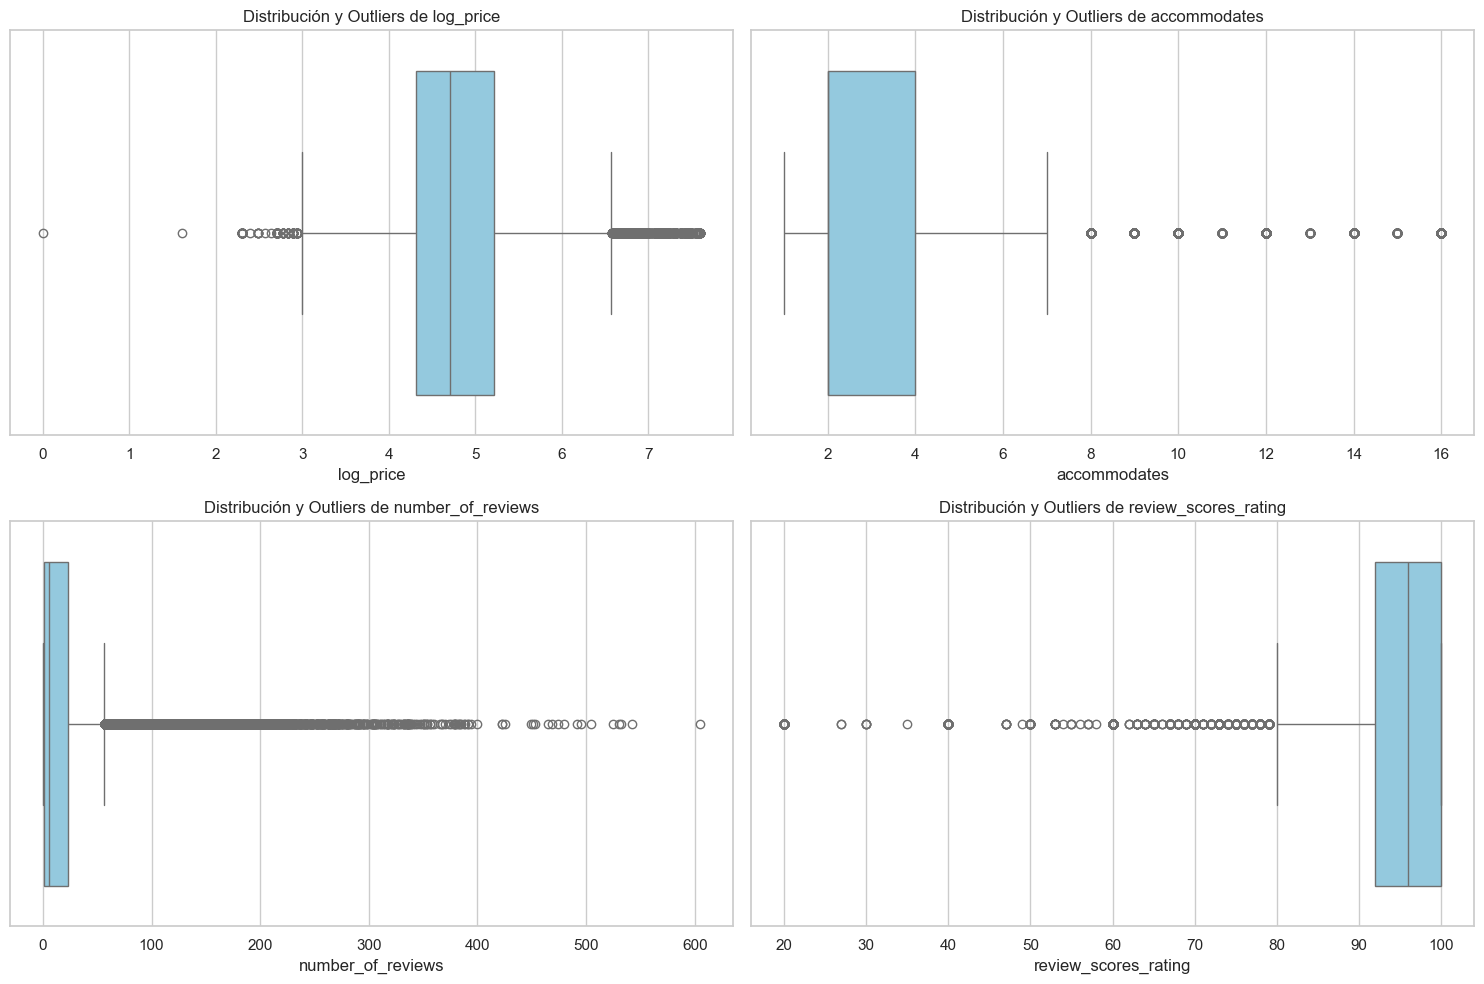

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set(style="whitegrid")

# Elegimos las variables con más outliers que identificamos antes
vars_to_plot = ['log_price', 'accommodates', 'number_of_reviews', 'review_scores_rating']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    sns.boxplot(x=datos[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f'Distribución y Outliers de {col}', fontsize=12)

plt.tight_layout()
plt.show()

# FEATURE ENGINEERING

In [12]:
print("\nFEATURE ENGINEERING")

# =====================
# CREACION DE VARIABLES
# =====================

# Validacion de columnas necesarias y creación de price_real y price_per_room
if 'log_price' in datos.columns and 'bedrooms' in datos.columns:
  # Convertimos log_price a precio real
  datos['price_real'] = np.exp(datos['log_price'])

  # Precio por habitacion (evitando division entre cero)
  datos['price_per_room'] = datos['price_real'] / (datos['bedrooms']+ 1)
else:
  missing_cols = []
  if 'log_price' not in datos.columns:
      missing_cols.append('log_price')
  if 'bedrooms' not in datos.columns:
      missing_cols.append('bedrooms')
  if missing_cols:
      print(f"Advertencia: No se pudieron crear 'price_real' y 'price_per_room' porque faltan las columnas: {', '.join(missing_cols)}")

# Segmentacion de precios (en base a precio real)
if 'price_real' in datos.columns:
  datos['price_segment'] = pd.qcut(
      datos['price_real'],
      q = 3,
      labels=['Bajo','Medio','Alto']
  )
else:
  print("Advertencia: No se pudo crear 'price_segment' porque 'price_real' no existe.")


FEATURE ENGINEERING


In [13]:
# ==============================
# VALIDACION DE VARIABLES NUEVAS
# ==============================

print("\nCOLUMNAS NUEVAS CREADAS:")
created_cols_report = []
if 'price_real' in datos.columns:
    created_cols_report.append('price_real')
if 'price_per_room' in datos.columns:
    created_cols_report.append('price_per_room')
if 'price_segment' in datos.columns:
    created_cols_report.append('price_segment')
print(created_cols_report)

print("\nVISTA DE VARIABLES RELEVANTES:")
display_cols = [col for col in ['log_price', 'price_real', 'bedrooms', 'price_per_room', 'price_segment'] if col in datos.columns]
if display_cols:
    display(datos[display_cols].head(10))
else:
    print("No hay variables relevantes para mostrar después de la creación.")


COLUMNAS NUEVAS CREADAS:
['price_real', 'price_per_room', 'price_segment']

VISTA DE VARIABLES RELEVANTES:


,log_price,price_real,bedrooms,price_per_room,price_segment
0,5.010635,150.0,1.0,75.00,Medio
1,5.129899,169.0,3.0,42.25,Alto
2,4.976734,145.0,1.0,72.50,Medio
3,6.620073,750.0,2.0,250.00,Alto
4,4.744932,115.0,0.0,115.00,Medio
5,4.442651,85.0,1.0,42.50,Bajo
6,4.418841,83.0,1.0,41.50,Bajo
7,4.787492,120.0,1.0,60.00,Medio
8,4.787492,120.0,1.0,60.00,Medio
9,3.583519,36.0,1.0,18.00,Bajo


In [14]:
# ==========================================
# ESTADISTICA DESCRIPTIVA (NUEVAS VARIABLES)
# ==========================================

print("\n ESTADISTICA DESCRIPTIVA (NUEVAS VARIABLES):")
desc_cols = [col for col in ['price_real', 'price_per_room'] if col in datos.columns]
if desc_cols:
    display(datos[desc_cols].describe())
else:
    print("No hay variables para describir.")


 ESTADISTICA DESCRIPTIVA (NUEVAS VARIABLES):


,price_real,price_per_room
count,74111.000000,74020.000000
mean,160.370849,71.256914
std,168.580415,66.183141
min,1.000000,0.500000
25%,75.000000,35.000000
50%,111.000000,53.333333
75%,185.000000,85.000000
max,1999.000000,1850.000000


# VISUALIZACION DE GRAFICAS

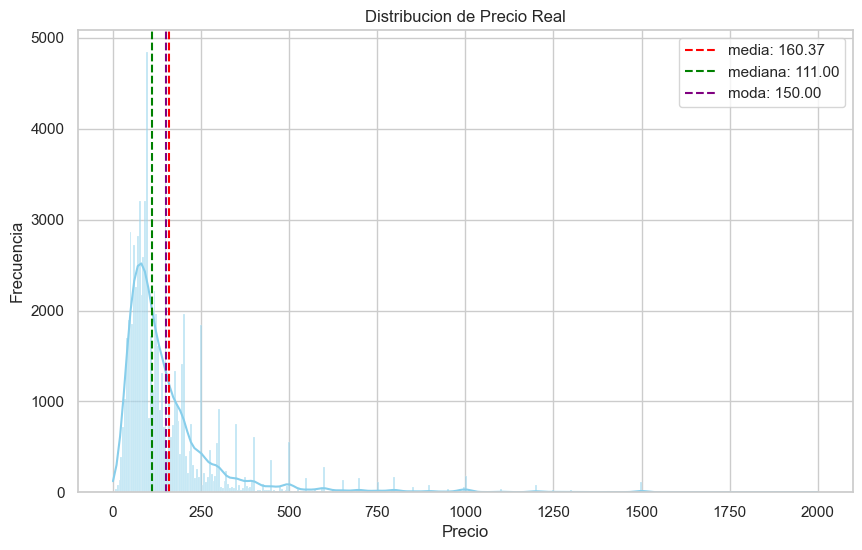

In [15]:
# ================================
# DISTRIBUCION DE NUEVAS VARIABLES
# ================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ================================
# GRAFICA DISTRIBUCION PRECIO REAL
# ================================
# CALCULO DE METRICAS
# ================================

media = datos['price_real'].mean()
mediana = datos['price_real'].median()
moda = datos['price_real'].mode()[0] #Tomamos la primera, que se repite más

#Grafica distribucion de precio
if 'price_real' in datos.columns:
  plt.figure(figsize=(10, 6))
  sns.histplot(datos['price_real'], kde=True, color='skyblue')

  #Líneas verticales
  plt.axvline(media, color='red', linestyle='--', label=f'media: {media:.2f}')
  plt.axvline(mediana, color='green', linestyle='--', label=f'mediana: {mediana:.2f}')
  plt.axvline(moda, color='purple', linestyle='--', label=f'moda: {moda:.2f}')

  #Titulos
  plt.title("Distribucion de Precio Real")
  plt.xlabel("Precio")
  plt.ylabel("Frecuencia")
  plt.legend()
  plt.show()
else:
    print("No se puede graficar la distribucion de 'price_real' porque no existe.")

# **Interpretacion de la grafica**

---
En esta grafica se puede comparar la frecuencia con la que se compra un airbnb con su precio y podemos entender el comportamiento real del mercado de Airbnb.

---
## **Interpretacion de las Métricas centrales**
###Mediana ($111.00):
Es el valor más representativo del "usuario común". Nos dice que el 50% de las propiedades en tu dataset cuestan 111 o menos. Es la métrica más robusta porque no se deja afectar por las mansiones de 2000.

###Media ($160.37):
El promedio es significativamente más alto que la mediana. Esto confirma matemáticamente que tienes una asimetría positiva (sesgo a la derecha). Las propiedades de lujo están "empujando" el promedio hacia arriba, alejándolo de la realidad de la mayoría de los listados.

###Moda ($150.00):
Curiosamente, el precio que más se repite es 150. Esto suele ocurrir en Airbnb porque los anfitriones tienden a usar "precios psicológicos" o números redondos (100, 150, 200) al configurar sus anuncios.

---
## **Insights**

**Insight 1:**

Concentración de Oferta: La gran "joroba" de la gráfica se encuentra antes de los 250. El mercado es masivo y altamente competitivo en el rango de 75 a 175. Si un anfitrión quiere entrar en el mercado masivo, ese es su rango objetivo.

**Insight 2:**

Presencia de Outliers Extremos: La cola de la distribución llega hasta los 2000, pero la frecuencia (altura de las barras) es casi invisible después de los 1000.

**Insight 3:**

Brecha de Lujo: Existe una diferencia de casi 50 dolares entre lo que el promedio dicta (160 media) y lo que la mitad de los usuarios realmente encuentra (111 mediana). Esto sugiere que Airbnb tiene un segmento "Premium" muy marcado que distorsiona las estadísticas simples.

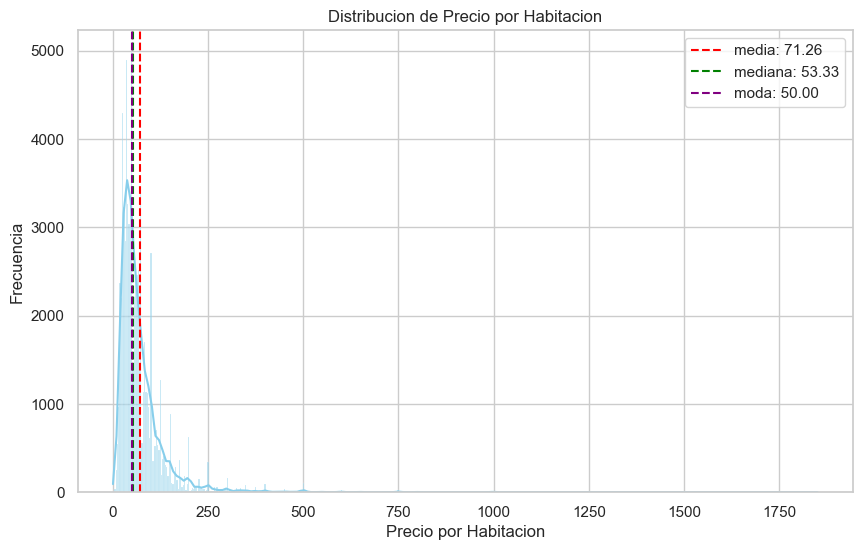

In [16]:
# ==========================================
# 2. GRAFICA PRINCIPAL PRECIO POR HABITACION
# ==========================================
# CALCULO DE METRICAS
# ==========================================

media = datos['price_per_room'].mean()
mediana = datos['price_per_room'].median()
moda = datos['price_per_room'].mode()[0]

if 'price_per_room' in datos.columns:
  plt.figure(figsize=(10, 6))
  sns.histplot(datos['price_per_room'], kde=True, color='skyblue')

  # Lineas de referencia
  plt.axvline(media, color='red', linestyle='--', label=f'media: {media:.2f}')
  plt.axvline(mediana, color='green', linestyle='--', label=f'mediana: {mediana:.2f}')
  plt.axvline(moda, color='purple', linestyle='--', label=f'moda: {moda:.2f}')

  #Titulos
  plt.title("Distribucion de Precio por Habitacion")
  plt.xlabel("Precio por Habitacion")
  plt.ylabel("Frecuencia")
  plt.legend()
  plt.show()
else:
    print("No se puede graficar la distribucion de 'price_per_room' porque no existe.")

# **Interpretacion de la grafica**
----
En esta grafica se puede comparar la frecuencia con la que se compra un airbnb con su precio por numero de habitacion, al normalizar el precio por el número de habitaciones, se elimina el "ruido" que generan las propiedades grandes (mansiones o casas multifamiliares) y se enfoca el valor real de la unidad habitacional.

---
##**Interpretacion de las Métricas centrales**
###Moda (50.00):
Es el valor más frecuente. Esto sugiere que $50 es el "punto dulce" o el estándar de la industria para el costo de una habitación individual en la plataforma. Es un número redondo y psicológicamente atractivo para los huéspedes.

###Mediana ($53.33):
Está muy cerca de la moda. Esto nos dice que el mercado está muy estandarizado: el 50% de las habitaciones se rentan por aproximadamente 53 dólares o menos.

###Media ($71.24):
Sigue siendo la métrica más alta debido a la asimetría, pero la brecha con la mediana se ha reducido (comparado con la gráfica de precio total). Esto significa que la "unidad habitación" es más estable que la "unidad propiedad".

---
##**Insights**
**Insight 1:**

Estandarización del Costo: Al dividir el precio por habitaciones, la mayoría de los datos se comprimen en el rango de 25 a 100 dolares. Esto indica que, independientemente de si la propiedad es grande o pequeña, el valor percibido por cada habitación adicional tiende a estabilizarse en este rango.

**Insight 2:**

Identificación de "Premium Real": Las propiedades que mantienen un price_per_room por encima de los $250 (los pequeños picos que ves a la derecha) son el verdadero segmento de lujo. No son caras porque sean grandes, sino porque cada una de sus habitaciones tiene un valor intrínseco muy alto (ubicación, acabados, servicios).

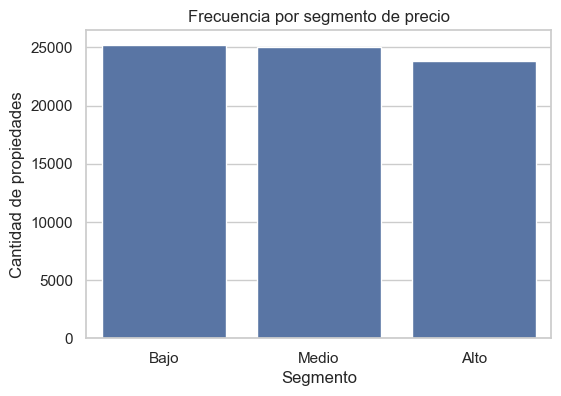


INSIGHT AUTOMATICO:
Distribucion por segmento:
price_segment
Bajo     25215
Medio    25040
Alto     23856
Name: count, dtype: int64

Precio promedio por segmento:
price_segment
Bajo      60.084751
Medio    116.685423
Alto     312.223508
Name: price_real, dtype: float64


In [17]:
# ===========================
# GRAFICA SEGMENTACION VISUAL
# ===========================
# CALCULO DE METRICAS
# ===========================
if 'price_segment' in datos.columns:

  plt.figure(figsize=(6, 4))
  sns.countplot(x='price_segment', data=datos)

  plt.title("Frecuencia por segmento de precio")
  plt.xlabel("Segmento")
  plt.ylabel("Cantidad de propiedades")
  plt.show()

  print("\nINSIGHT AUTOMATICO:")

  print("Distribucion por segmento:")
  print(datos['price_segment'].value_counts())

  print("\nPrecio promedio por segmento:")
  print(datos.groupby('price_segment')['price_real'].mean())
else:
    print("No se puede graficar la segmentación de propiedades por precio porque 'price_segment' no existe.")

# **Interpretacion de la grafica**

---
###Equilibrio en el Dataset (Distribución por Segmento)

La gráfica de barras muestra alturas muy similares, y la consola lo confirma con números cercanos (~25,000 registros por grupo).

El dataset es muy robusto. No hay una falta de datos en el sector de lujo ni en el económico. Esto es ideal para entrenar modelos de clasificación en el futuro, ya que las clases están balanceadas.

La ligera variación (el segmento "Alto" tiene unos 1,300 registros menos) suele deberse a cómo el algoritmo maneja los valores que se repiten exactamente en los límites de los cortes.

---
###El Salto de Precios

Segmento Bajo ($60.08): Representa la oferta económica, probablemente habitaciones compartidas o estudios pequeños.

Segmento Medio ($116.68): El precio casi se duplica respecto al bajo. Este es el "corazón" de Airbnb, donde reside la mayor parte de la competencia de apartamentos completos estándar.

Segmento Alto ($312.22): El precio casi se triplica respecto al medio

**Insight Crítico:**
 La diferencia entre el nivel Medio y el Alto es mucho más drástica que entre el Bajo y el Medio. Esto confirma que el segmento "Alto" no es solo "un poco más caro", sino que representa un mercado de lujo con características de propiedad radicalmente distintas (más habitaciones, ubicaciones premium o servicios de alta gama).

---
#**Insights**

**Insight 1:**

Estratificación del Mercado: "El mercado de Airbnb analizado se divide en tercios claramente diferenciados, donde el segmento de lujo (Alto) tiene un costo de oportunidad 5 veces mayor ($312 vs $60) que el segmento económico."

**Insight 2:**

Punto de Inflexión: "Existe un salto de valor significativo al pasar del segmento medio al alto, lo que sugiere que las propiedades de más de $200 (aproximadamente donde empezaría el corte alto) ofrecen amenidades que justifican un incremento del 167% en el precio promedio respecto al estándar del mercado."

**Insight 3:**

Potencial de Negocio: "Para un inversionista, el segmento medio parece ser el más estable para volumen, pero el segmento alto ofrece el mayor margen de ingresos por propiedad, a pesar de tener una cantidad de oferta ligeramente menor."

# 6. EDA Visual

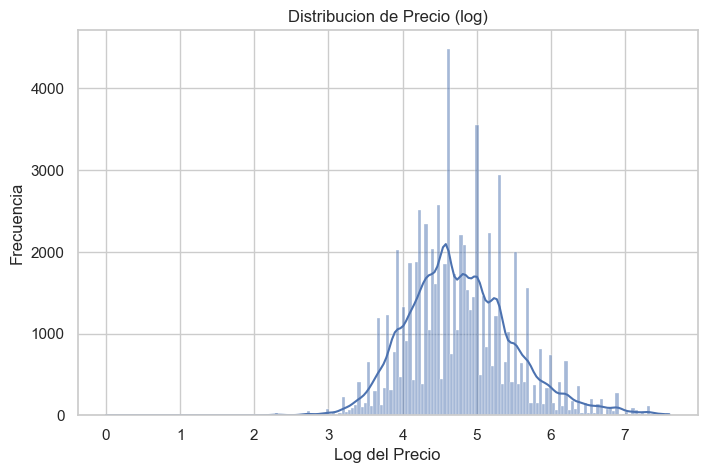

In [18]:
# Distribucion del precio

# Despues de aplicar log, los precios se distribuyen de forma mas equilibrada
# Comprime valores altos, reduce el efecto de outliers, hace la distribucion mas interpretable

plt.figure(figsize=(8, 5))
sns.histplot(datos['log_price'], kde = True)
plt.title('Distribucion de Precio (log)')
plt.xlabel('Log del Precio')
plt.ylabel("Frecuencia")
plt.show()

# Interpretacion de la grafica
En las gráficas anteriores, los precios de 1,000 o 2,000 "estiraban" la gráfica hacia la derecha, haciendo que no se visualizaran correctamente los detalles de los precios bajos.

Al aplicar el logaritmo, los valores grandes se "encogen" y los pequeños se "expanden". Esto permite observar la estructura interna de los datos.

Ahora vemos que la mayoría de los datos se concentran simétricamente alrededor del valor 4.7 (que en escala real es aproximadamente $110).

---
**Los "Picos" o Spikes en la Distribución**

Hay barras individuales que sobresalen mucho del resto (especialmente cerca del 4.6, 5.0 y 5.3).

Insight: Estos picos representan los precios psicológicos. Los anfitriones no suelen poner precios como 107.43 dolares; prefieren números redondos como 100, 150 o 200 dolares. Al aplicar el logaritmo, esos números redondos aparecen como picos constantes en la frecuencia.
El pico más alto está cerca del 4.6, que corresponde a los $100. Es el precio estándar por excelencia en la plataforma.

---
**Interpretación de los Extremos**

Lado Izquierdo (Valores < 3): Son propiedades extremadamente baratas (menos de $20). En la escala real eran casi imperceptibles, pero aquí se puede apreciar como forman una pequeña "cola" que podría representar errores de datos o listados de prueba.

Lado Derecho (Valores > 6.5): Representan el lujo extremo ($650+). Aunque son pocos, ahora se aprecia su distribución real y cómo se integran al ecosistema sin distorsionar el promedio de manera tan agresiva.

---

"La transformación logarítmica del precio revela una distribución normal, lo que confirma que el mercado de Airbnb es estadísticamente predecible una vez que se controla la volatilidad de los precios extremos.

La presencia de picos marcados en la distribución sugiere un fuerte componente de precios psicológicos por parte de los anfitriones, concentrándose la mayor densidad de oferta en el rango de los $100 USD (log ~4.6)."

#Diagnostico de Correlaciones y factores determinantes


MAPA DE CALOR: IDENTIFICANDO VARIABLES QUE INFLUYEN EN EL PRECIO


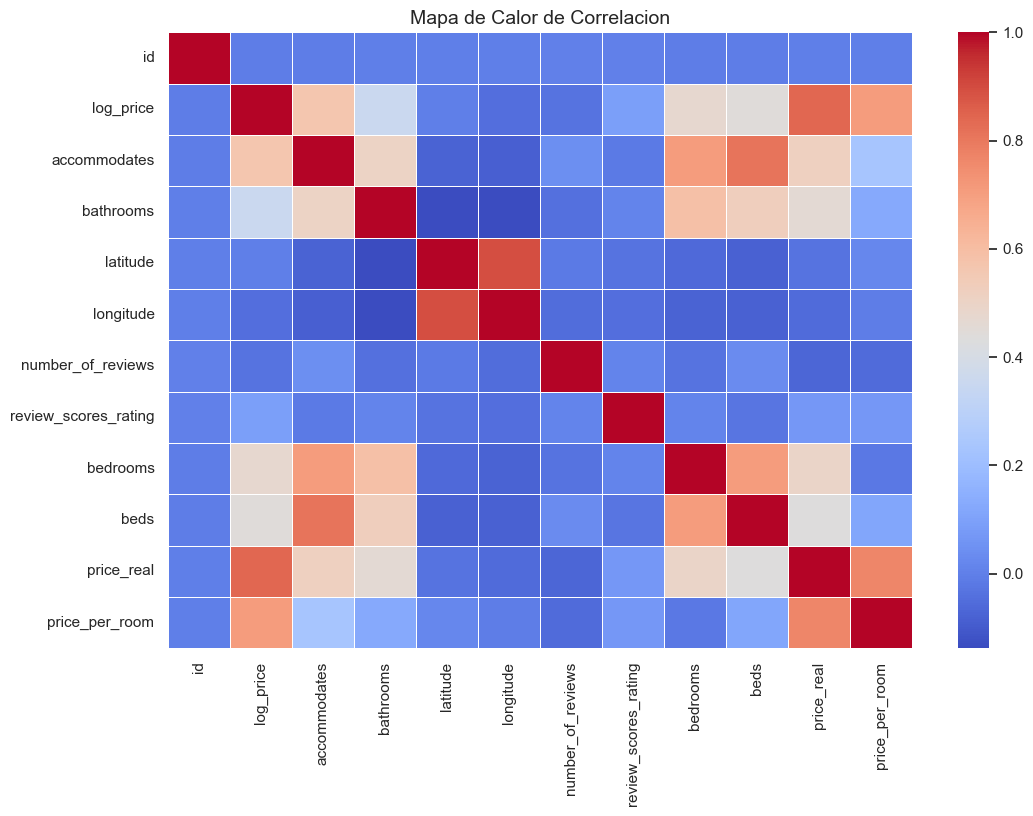

Las 5 variables mas correlacionadas con el precio son:
log_price         1.000000
price_real        0.840001
price_per_room    0.709757
accommodates      0.567574
bedrooms          0.473212
beds              0.442153
Name: log_price, dtype: float64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =======================================
# MAPA DE CALOR (CORRELACIONES NUMERICAS)
# =======================================

print("\nMAPA DE CALOR: IDENTIFICANDO VARIABLES QUE INFLUYEN EN EL PRECIO")

plt.figure(figsize=(12, 8))

#Seleccionamos columnas numericas
columnas_numericas = datos.select_dtypes(include=[np.number])

# Calculamos matriz de correlacion
matriz_correlacion = columnas_numericas.corr()

#Crear mapa de calor
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor de Correlacion', fontsize=14)
plt.show()

#Extraemos numericamente las variables mas correlacionadas
print("Las 5 variables mas correlacionadas con el precio son:")
corelaciones_precio = matriz_correlacion["log_price"].sort_values(ascending=False)
print(corelaciones_precio.head(6))

# Boxplot

<Axes: xlabel='price_segment', ylabel='log_price'>

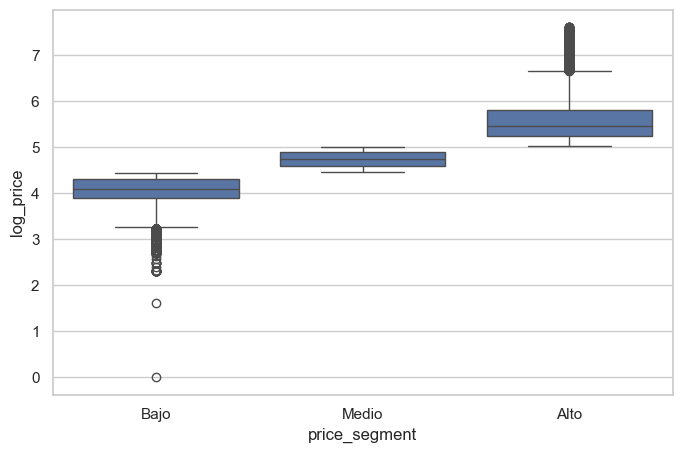

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='price_segment', y='log_price', data=datos)


**El Enigma del Segmento Bajo (Outliers Inferiores)**

Insight: Existen propiedades con precios extremadamente bajos (casi gratuitos en escala logarítmica). Esto podría indicar errores en la carga de datos por parte de los anfitriones o casos muy específicos de habitaciones compartidas en zonas rurales.

Recomendacion: filtrar precios menores a un umbral (ej. $10 USD) para que no sesguen tu futuro modelo.

**Compactación en el Segmento Medio**
La caja del segmento Medio es la más "delgada" o compacta.

Insight: Esto indica una alta homogeneidad. Las propiedades en este rango de precio son muy similares entre sí en cuanto a valor. Es el segmento más predecible del mercado. Si se predicen precios, este grupo tendrá el menor error.

**Dispersión y Lujo en el Segmento Alto**
La caja del segmento Alto es más alta y tiene muchos puntos por encima del bigote superior.

Insight: Hay una gran variabilidad. Incluso dentro del tercio más caro, existen "super-outliers" (mansiones o islas privadas) que están muy por encima del promedio del grupo de lujo. El segmento alto es el más difícil de estandarizar.

# EXPORTACION FINAL

In [21]:
import os

# Definimos la ruta de salida
# '..' sale de notebooks, 'data' entra a la carpeta y el nombre del archivo
ruta_salida = os.path.join('..', 'data', 'airbnb_procesado.csv')

# Guardamos el archivo
datos_limpios.to_csv(ruta_salida, index=False)

print(f"\nDataset guardado en: {ruta_salida}")
print("Dataset listo para modelado")


Dataset guardado en: ..\data\airbnb_procesado.csv
Dataset listo para modelado


# REGRESION LINEAL Y ENTRENAMIENTO DEL MODELO

In [22]:
#0:Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Modelado
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")

In [23]:
X = datos[['accommodates']]
y = datos['price_real']

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train.values.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"Pendiente (m): {pendiente:.2f}")
print(f"Intercepto (b): {intercepto:.2f}")

Pendiente (m): 40.68
Intercepto (b): 31.89


In [26]:
y_pred = modelo.predict(X_test.values.reshape(-1, 1))

resultado = pd.DataFrame({
    'Real': y_test,
    'Prediccion': y_pred
})

display(resultado)

,Real,Prediccion
4079,45.0,113.244234
33735,140.0,113.244234
69475,140.0,235.279395
454,130.0,275.957782
25153,39.0,113.244234
...,...,...
4775,200.0,194.601008
14723,75.0,194.601008
29953,85.0,113.244234
38582,215.0,438.671330


In [27]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadratico medio (MSE): {mse:.2f}")
print(f"Raiz del error cuadratico medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de determinacion (R^2): {r2:.2f}")

Error cuadratico medio (MSE): 21660.00
Raiz del error cuadratico medio (RMSE): 147.17
Coeficiente de determinacion (R^2): 0.26


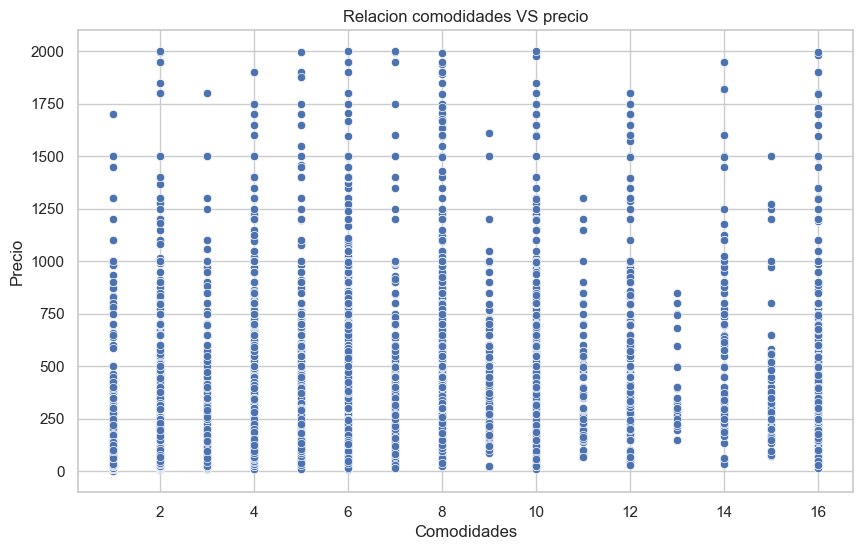

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=datos, x='accommodates', y='price_real')

plt.title('Relacion comodidades VS precio')
plt.xlabel('Comodidades')
plt.ylabel('Precio')

plt.show()

Distribución de Precios por Distrito (Boxplot o Bar Chart)

C:\Users\oled\AppData\Local\Temp\ipykernel_18064\104015153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood', y='price_real', data=datos_top_neighbourhoods, estimator='mean', palette='viridis')


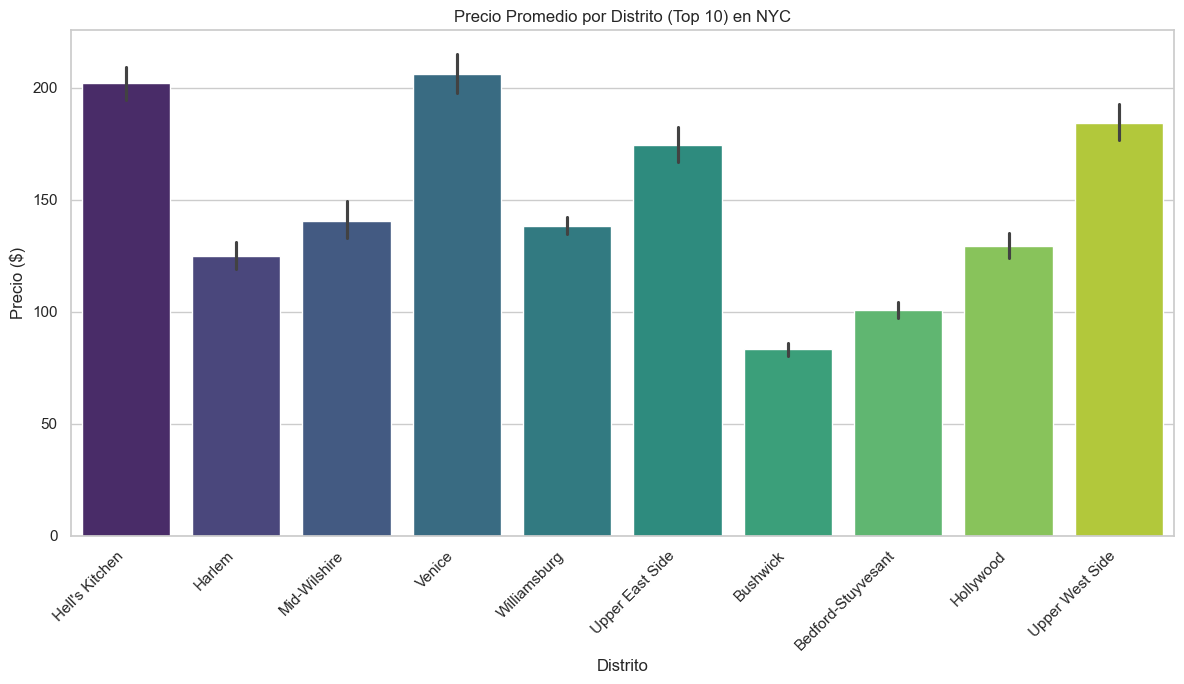

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener los 10 barrios con más listados para una visualización clara
top_10_neighbourhoods = datos['neighbourhood'].value_counts().head(10).index
datos_top_neighbourhoods = datos[datos['neighbourhood'].isin(top_10_neighbourhoods)]

plt.figure(figsize=(12,7))
sns.barplot(x='neighbourhood', y='price_real', data=datos_top_neighbourhoods, estimator='mean', palette='viridis')
plt.title('Precio Promedio por Distrito (Top 10) en NYC')
plt.ylabel('Precio ($)')
plt.xlabel('Distrito')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor lectura
plt.tight_layout()
plt.show()

Relación entre Disponibilidad y Calificación

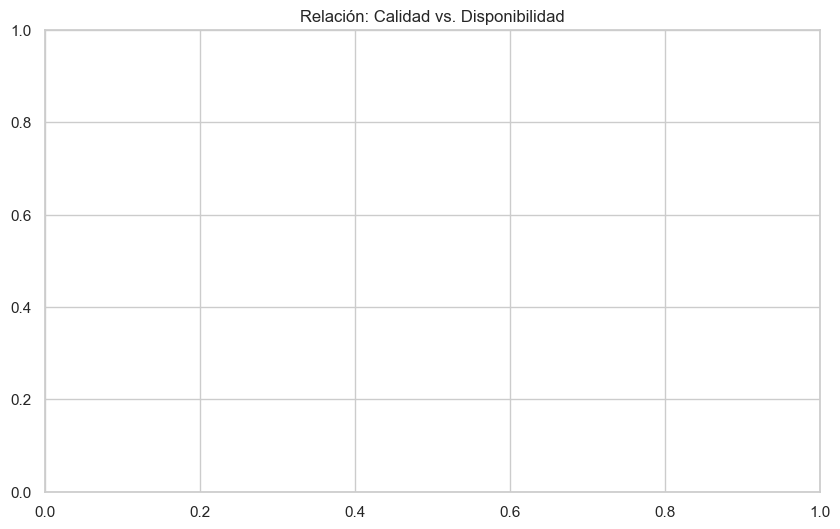

In [30]:
plt.figure(figsize=(10,6))
# sns.scatterplot(x='review_scores_rating', y='availability_365', data=datos, alpha=0.5, color='orange') # availability_365 and df do not exist in the current dataframe
plt.title('Relación: Calidad vs. Disponibilidad')
plt.show()

C:\Users\oled\AppData\Local\Temp\ipykernel_18064\1904587341.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='host_identity_verified', y='review_scores_rating', data=datos, palette='Blues_d')


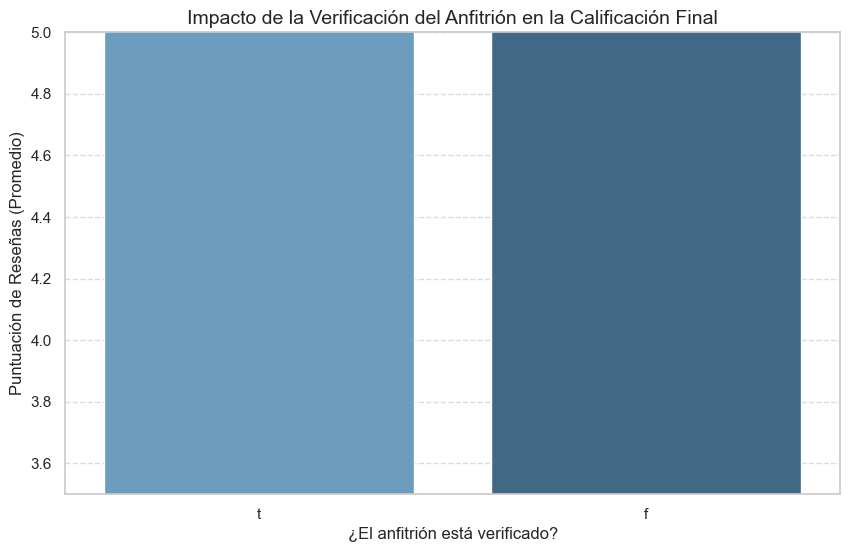

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Simulando una métrica de "Nivel de Confianza" basada en Verificación y Tasa de Respuesta
# En tu dataset, esto se relaciona con 'host_identity_verified' y 'review_scores_rating'

plt.figure(figsize=(10, 6))
sns.barplot(x='host_identity_verified', y='review_scores_rating', data=datos, palette='Blues_d')

plt.title('Impacto de la Verificación del Anfitrión en la Calificación Final', fontsize=14)
plt.xlabel('¿El anfitrión está verificado?', fontsize=12)
plt.ylabel('Puntuación de Reseñas (Promedio)', fontsize=12)
plt.ylim(3.5, 5) # Enfocamos la vista en el rango de excelencia
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# EXPORTAR MODELO

In [32]:
# ==============================
# EXPORTAR MODELO
# ==============================
import joblib
import os

# Asegurarnos de que la carpeta existe
if not os.path.exists('../models'):
    os.makedirs('../models')

# CORRECTO: Guardamos los objetos entrenados, no los resultados
objetos_modelo = {
    'modelo': modelo,       # El objeto LinearRegression entrenado
    'escalador': None       # Si no usaste un StandardScaler/MinMaxScaler, pon None
}

# Guardar el archivo
joblib.dump(objetos_modelo, '../models/modelo_airbnb.joblib')

print("¡Cerebro guardado correctamente! El archivo ya contiene el modelo listo para predecir.")

¡Cerebro guardado correctamente! El archivo ya contiene el modelo listo para predecir.
